# Trabajo 1 — Lectura de datos y análisis descriptivo (Bike Sharing Dataset)

**Variable respuesta:** `cnt` (total de alquileres).
**Objetivo:** leer el dataset y realizar un análisis descriptivo completo: missing, split de modelización/validación, correlaciones, distribuciones y gráficos.

**Dataset:** Bike Sharing Dataset (UCI).

In [14]:
# Ajusta la carpeta si lo necesitas:
# DATA_DIR = Path(".")
from pathlib import Path

import pandas as pd


DATA_DIR = Path("./data")  # si estás en un entorno como el que me compartiste

DATASET = "day"   # "day" o "hour"

file_map = {
    "day": DATA_DIR / "day.csv",
    "hour": DATA_DIR / "hour.csv",
}

df = pd.read_csv(file_map[DATASET])

print("Dataset:", DATASET)
print("Shape:", df.shape)
display(df.head())

Dataset: day
Shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Diccionario de datos + desnormalización

Según el Readme: `season`, `weathersit`, `yr`, etc., y variables meteorológicas normalizadas:
`temp` se dividió por 41, `atemp` por 50, `hum` por 100, `windspeed` por 67.

In [15]:
season_map = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_map = {
    1: "Clear/Partly cloudy",
    2: "Mist/Cloudy",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Snow/Fog"
}
year_map = {0: "2011", 1: "2012"}
weekday_map = {0:"Sun", 1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat"}

df["dteday"] = pd.to_datetime(df["dteday"])

# Etiquetas interpretables (sin perder el código numérico original)
df["season_lbl"] = df["season"].map(season_map)
df["weathersit_lbl"] = df["weathersit"].map(weather_map)
df["yr_lbl"] = df["yr"].map(year_map)
df["weekday_lbl"] = df["weekday"].map(weekday_map)

# Desnormalización (para gráficos e interpretación; conserva también las columnas originales)
df["temp_c"] = df["temp"] * 41.0
df["atemp_c"] = df["atemp"] * 50.0
df["hum_pct"] = df["hum"] * 100.0
df["windspeed_raw"] = df["windspeed"] * 67.0

# Si es hourly, crea datetime completo
if "hr" in df.columns:
    df["datetime"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")

display(df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,registered,cnt,season_lbl,weathersit_lbl,yr_lbl,weekday_lbl,temp_c,atemp_c,hum_pct,windspeed_raw
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,654,985,spring,Mist/Cloudy,2011,Sat,14.110847,18.18125,80.5833,10.749882
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,670,801,spring,Mist/Cloudy,2011,Sun,14.902598,17.68695,69.6087,16.652113
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,1229,1349,spring,Clear/Partly cloudy,2011,Mon,8.050924,9.47025,43.7273,16.636703
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,1454,1562,spring,Clear/Partly cloudy,2011,Tue,8.200000,10.60610,59.0435,10.739832
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,1518,1600,spring,Clear/Partly cloudy,2011,Wed,9.305237,11.46350,43.6957,12.522300


## Revisión: tipos, duplicados, estadísticos

In [16]:
import numpy as np

print(df.info())

print("\nDuplicados:", df.duplicated().sum())

# Estadísticos numéricos
display(df.describe(include=[np.number]).T)

# Conteos de categorías (útil para comentar)
cat_cols = ["season", "weathersit", "yr", "mnth", "weekday", "workingday", "holiday"]
if "hr" in df.columns:
    cat_cols.append("hr")

for c in cat_cols:
    print(f"\n{c} value_counts:")
    display(df[c].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   instant         731 non-null    int64         
 1   dteday          731 non-null    datetime64[us]
 2   season          731 non-null    int64         
 3   yr              731 non-null    int64         
 4   mnth            731 non-null    int64         
 5   holiday         731 non-null    int64         
 6   weekday         731 non-null    int64         
 7   workingday      731 non-null    int64         
 8   weathersit      731 non-null    int64         
 9   temp            731 non-null    float64       
 10  atemp           731 non-null    float64       
 11  hum             731 non-null    float64       
 12  windspeed       731 non-null    float64       
 13  casual          731 non-null    int64         
 14  registered      731 non-null    int64         
 15  cnt             7

,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000000,211.165812,1.000000,183.500000,366.000000,548.500000,731.000000
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
yr,731.0,0.500684,0.500342,0.000000,0.000000,1.000000,1.000000,1.000000
mnth,731.0,6.519836,3.451913,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,731.0,2.997264,2.004787,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
temp,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667
atemp,731.0,0.474354,0.162961,0.079070,0.337842,0.486733,0.608602,0.840896



season value_counts:


season
1    181
2    184
3    188
4    178
Name: count, dtype: int64


weathersit value_counts:


...

weekday
0    105
1    105
2    104
3    104
4    104
5    104
6    105
Name: count, dtype: int64


workingday value_counts:


workingday
0    231
1    500
Name: count, dtype: int64


holiday value_counts:


holiday
0    710
1     21
Name: count, dtype: int64

## Missing values (y tratamiento si existieran)

En este dataset suele venir completo, pero igual lo documentas.

In [17]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Tratamiento genérico (solo aplica si hay missing)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

df_imputed = df.copy()
for c in num_cols:
    if df_imputed[c].isna().any():
        df_imputed[c] = df_imputed[c].fillna(df_imputed[c].median())

for c in obj_cols:
    if df_imputed[c].isna().any():
        df_imputed[c] = df_imputed[c].fillna(df_imputed[c].mode().iloc[0])

df = df_imputed

Series([], dtype: int64)

## Variables “fuga” (leakage) `casual` y `registered`

El Readme indica que `cnt` **= total incluyendo casual + registered.**

Por tanto, para analizar predictoras reales de `cnt`, **no conviene** usar `casual` y `registered` (son componentes del target).

In [18]:
# Verificación de la relación (siempre debería cumplirse)
leak_check = (df["casual"] + df["registered"] - df["cnt"]).abs().sum()
print("Suma |(casual + registered) - cnt| =", leak_check)

Suma |(casual + registered) - cnt| = 0


## Split: modelización vs validación (recomendado: temporal)

El trabajo pide determinar conjunto de modelización y validación.

**Opción A (muy clara): Train = 2011, Valid = 2012**

In [19]:
train = df[df["yr"] == 0].copy()
valid = df[df["yr"] == 1].copy()

print("Train:", train.shape, "Valid:", valid.shape)
print(train["dteday"].min(), "→", train["dteday"].max())
print(valid["dteday"].min(), "→", valid["dteday"].max())

Train: (365, 24) Valid: (366, 24)
2011-01-01 00:00:00 → 2011-12-31 00:00:00
2012-01-01 00:00:00 → 2012-12-31 00:00:00


**Opción B: 80/20 cronológico (por fecha)**

In [20]:
df_sorted = df.sort_values("dteday" if "datetime" not in df.columns else "datetime").reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

train2 = df_sorted.iloc[:split_idx].copy()
valid2 = df_sorted.iloc[split_idx:].copy()

print("Train2:", train2.shape, "Valid2:", valid2.shape)

Train2: (584, 24) Valid2: (147, 24)


## Correlaciones con `cnt` (sin fuga)

cnt              1.000000
atemp            0.631066
atemp_c          0.631066
temp             0.627494
temp_c           0.627494
yr               0.566710
season           0.406100
mnth             0.279977
weekday          0.067443
workingday       0.061156
holiday         -0.068348
hum             -0.100659
hum_pct         -0.100659
windspeed_raw   -0.234545
windspeed       -0.234545
weathersit      -0.297391
Name: cnt, dtype: float64

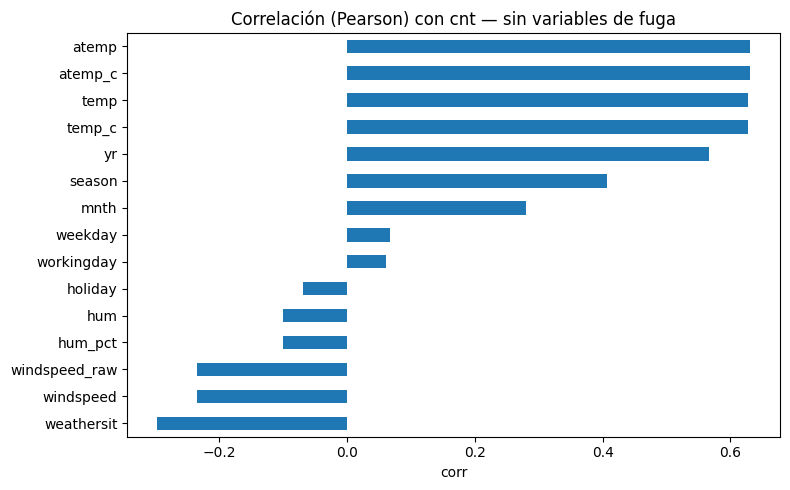

In [21]:
from matplotlib import pyplot as plt


target = "cnt"
exclude = {"cnt", "dteday", "datetime", "instant", "casual", "registered"}  # instant es índice; casual/registered fuga
num_features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

corr = df[num_features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
display(corr)

# Gráfico: correlación (magnitud) con cnt
plt.figure(figsize=(8, 5))
corr.drop(target).sort_values().plot(kind="barh")
plt.title("Correlación (Pearson) con cnt — sin variables de fuga")
plt.xlabel("corr")
plt.tight_layout()
plt.show()

## Matriz de correlación (para ver colinealidad, ej. `temp` vs `atemp`)

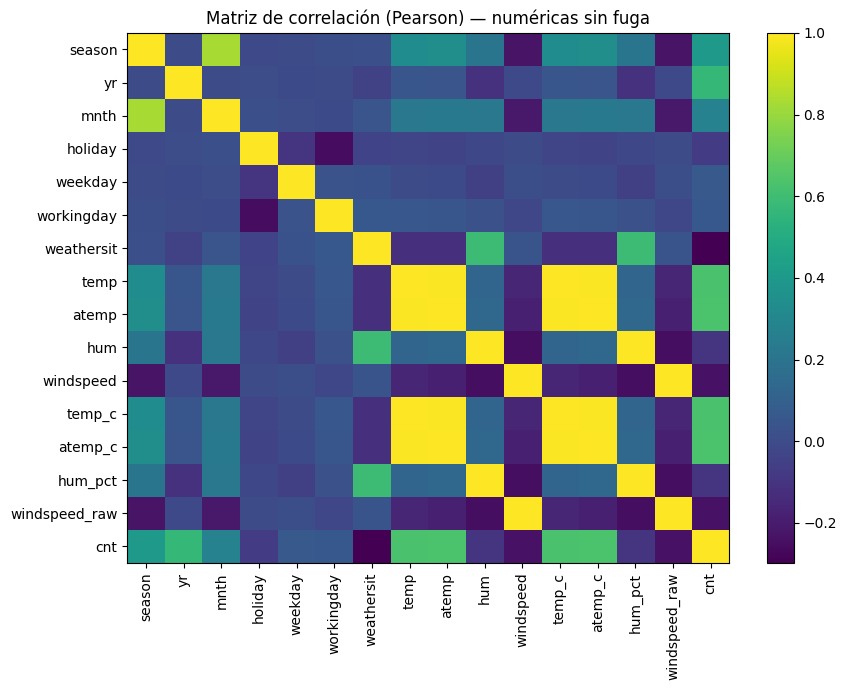

atemp            0.631066
atemp_c          0.631066
temp             0.627494
temp_c           0.627494
yr               0.566710
season           0.406100
weathersit       0.297391
mnth             0.279977
windspeed        0.234545
windspeed_raw    0.234545
Name: cnt, dtype: float64

In [22]:
corr_mat = df[num_features + [target]].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_mat, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
plt.title("Matriz de correlación (Pearson) — numéricas sin fuga")
plt.tight_layout()
plt.show()

# Top correlaciones absolutas (para comentar en informe)
abs_corr = corr.drop(target).abs().sort_values(ascending=False)
display(abs_corr.head(10))

## Distribuciones: `cnt` (y transformación log si está sesgada)

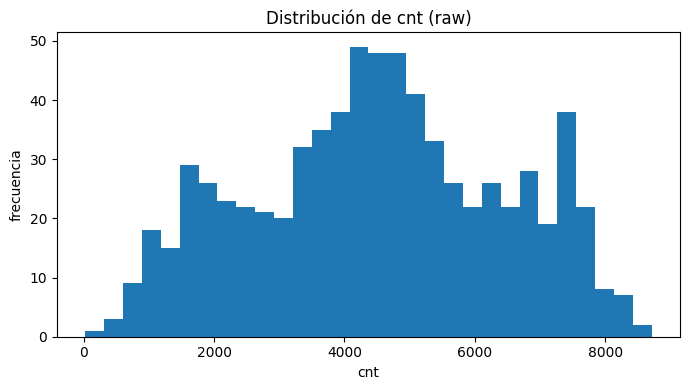

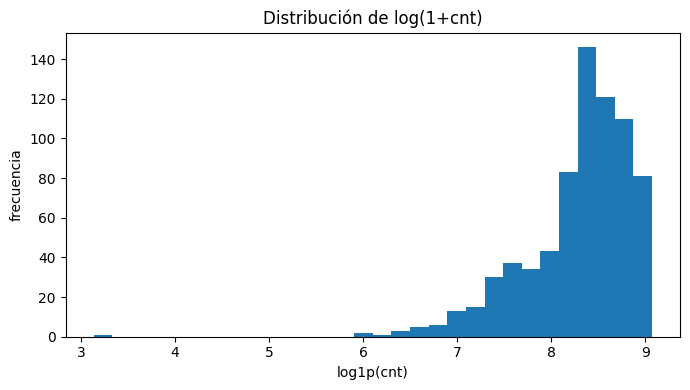

In [23]:
plt.figure(figsize=(7,4))
plt.hist(df["cnt"], bins=30)
plt.title("Distribución de cnt (raw)")
plt.xlabel("cnt")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.hist(np.log1p(df["cnt"]), bins=30)
plt.title("Distribución de log(1+cnt)")
plt.xlabel("log1p(cnt)")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

## `cnt` vs meteorología (scatter)

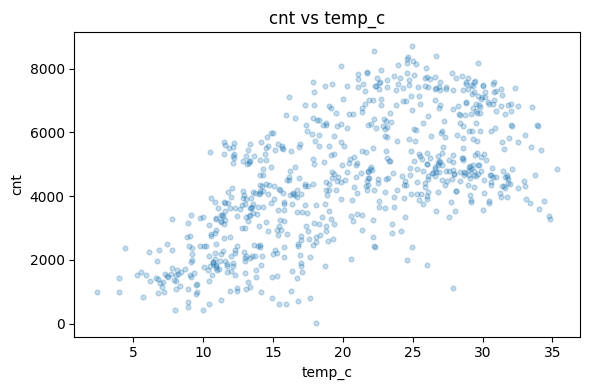

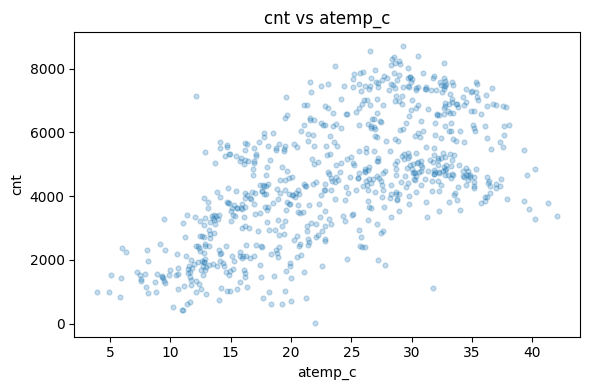

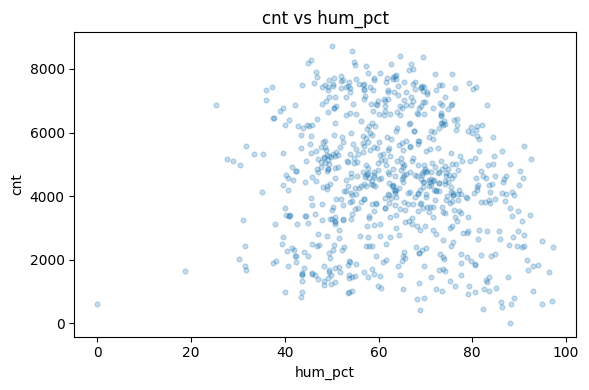

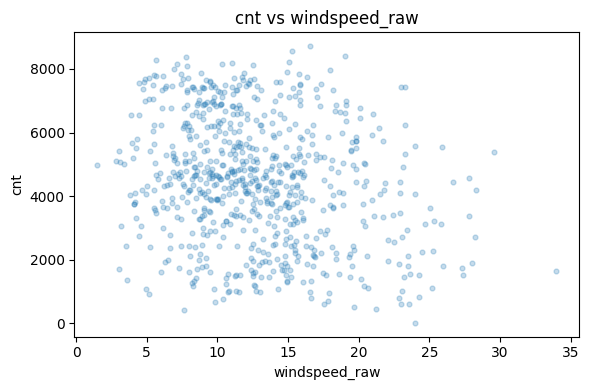

In [24]:
def scatter(x, y="cnt", alpha=0.25):
    plt.figure(figsize=(6,4))
    plt.scatter(df[x], df[y], s=12, alpha=alpha)
    plt.title(f"{y} vs {x}")
    plt.xlabel(x); plt.ylabel(y)
    plt.tight_layout()
    plt.show()

scatter("temp_c")
scatter("atemp_c")
scatter("hum_pct")
scatter("windspeed_raw")

## cnt por categorías (medias por season, weather, weekday, month…)

,mean,median,count
season_lbl,,,
fall,5644.303191,5353.5,188
spring,2604.132597,2209.0,181
summer,4992.331522,4941.5,184
winter,4728.162921,4634.5,178


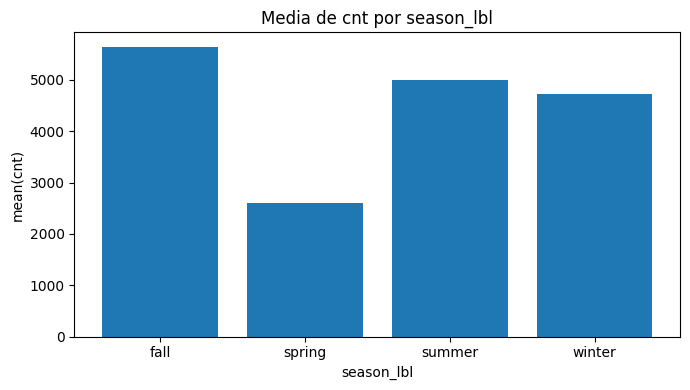

,mean,median,count
weathersit_lbl,,,
Clear/Partly cloudy,4876.786177,4844.0,463
Light Snow/Rain,1803.285714,1817.0,21
Mist/Cloudy,4035.862348,4040.0,247


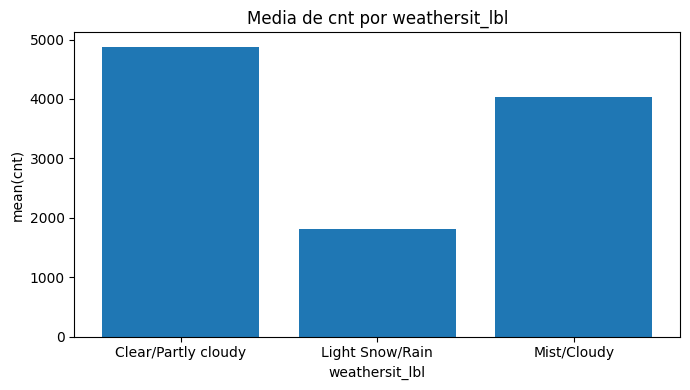

,mean,median,count
weekday_lbl,,,
Fri,4690.288462,4601.5,104
Mon,4338.123810,4359.0,105
Sat,4550.542857,4521.0,105
Sun,4228.828571,4334.0,105
Thu,4667.259615,4721.0,104
Tue,4510.663462,4576.5,104
Wed,4548.538462,4642.5,104


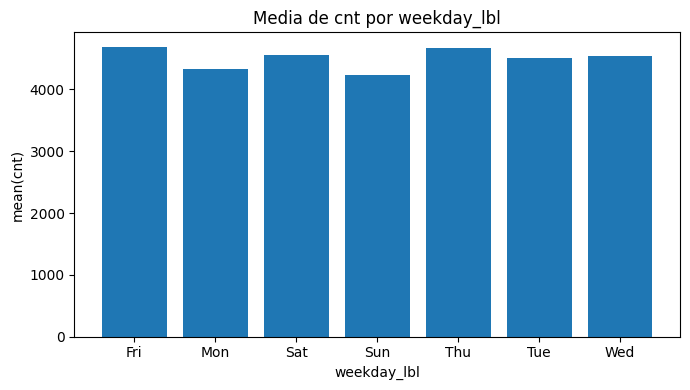

,mean,median,count
mnth,,,
1,2176.338710,1939.0,62
2,2655.298246,2402.0,57
3,3692.258065,3216.5,62
4,4484.900000,4293.5,60
5,5349.774194,4890.5,62
6,5772.366667,5308.5,60
7,5563.677419,5446.5,62
8,5664.419355,5229.5,62
9,5766.516667,5384.0,60


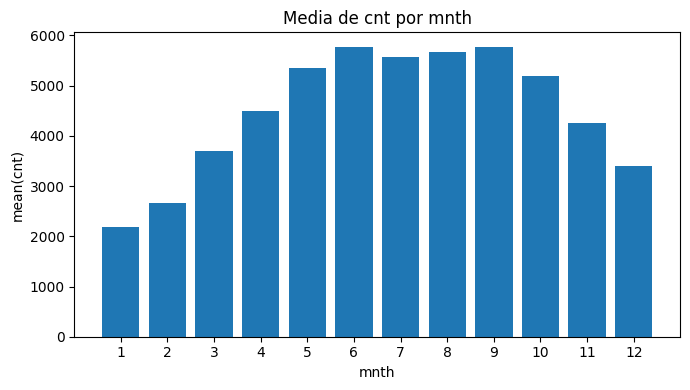

,mean,median,count
workingday,,,
0,4330.168831,4459.0,231
1,4584.820000,4582.0,500


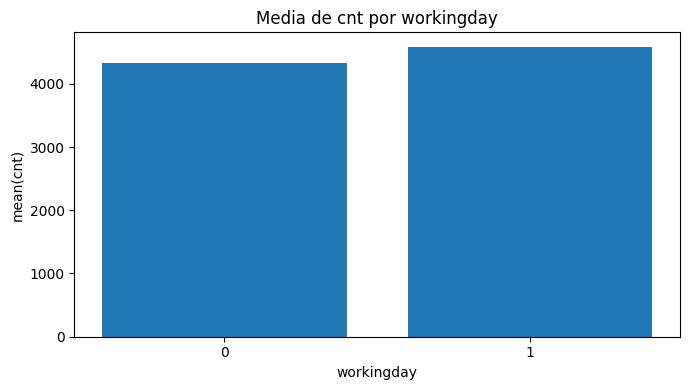

,mean,median,count
holiday,,,
0,4527.104225,4558.0,710
1,3735.000000,3351.0,21


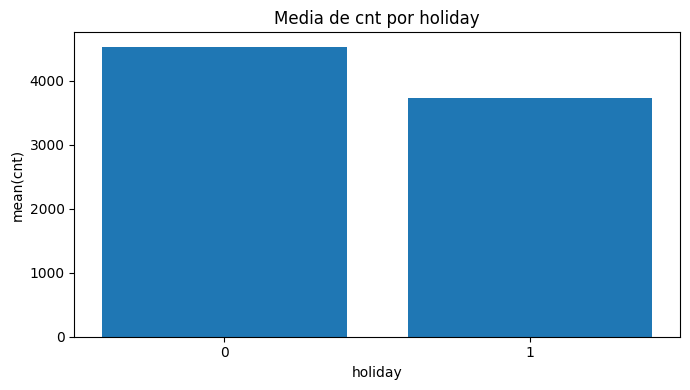

,mean,median,count
yr_lbl,,,
2011,3405.761644,3740.0,365
2012,5599.934426,5927.0,366


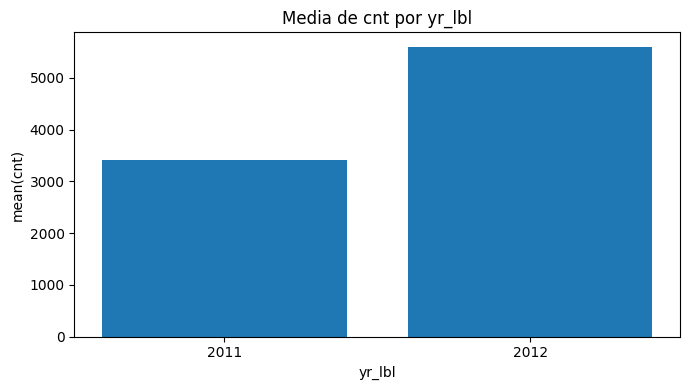

In [25]:
def plot_mean_by(cat_col, y="cnt"):
    grp = df.groupby(cat_col)[y].agg(["mean", "median", "count"]).sort_index()
    display(grp)

    plt.figure(figsize=(7,4))
    plt.bar(grp.index.astype(str), grp["mean"].values)
    plt.title(f"Media de {y} por {cat_col}")
    plt.xlabel(cat_col); plt.ylabel(f"mean({y})")
    plt.tight_layout()
    plt.show()

for c in ["season_lbl", "weathersit_lbl", "weekday_lbl", "mnth", "workingday", "holiday", "yr_lbl"]:
    plot_mean_by(c)

if "hr" in df.columns:
    plot_mean_by("hr")

## Series temporales (tendencia + estacionalidad visual)

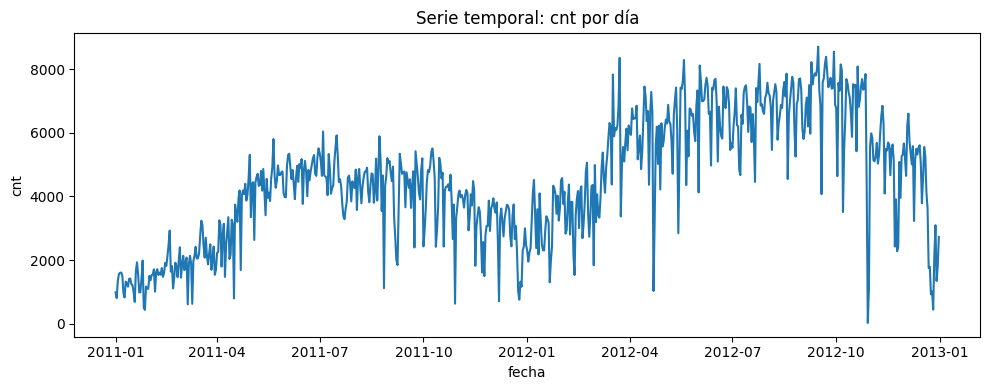

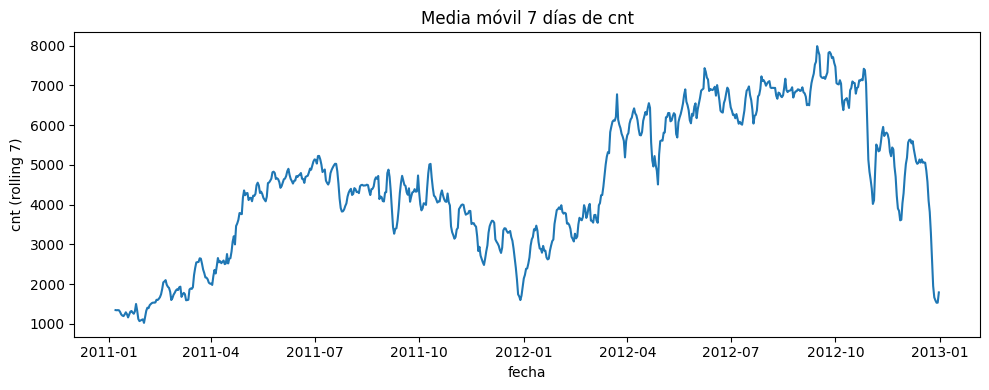

In [26]:
# Para day: dteday vs cnt
if "datetime" not in df.columns:
    tmp = df.sort_values("dteday")
    plt.figure(figsize=(10,4))
    plt.plot(tmp["dteday"], tmp["cnt"])
    plt.title("Serie temporal: cnt por día")
    plt.xlabel("fecha"); plt.ylabel("cnt")
    plt.tight_layout()
    plt.show()

    # Media móvil 7 días
    tmp2 = tmp.set_index("dteday")["cnt"].rolling(7).mean()
    plt.figure(figsize=(10,4))
    plt.plot(tmp2.index, tmp2.values)
    plt.title("Media móvil 7 días de cnt")
    plt.xlabel("fecha"); plt.ylabel("cnt (rolling 7)")
    plt.tight_layout()
    plt.show()

# Para hour: patrón por hora y por día de semana (heatmap manual)
if "datetime" in df.columns:
    pivot = df.pivot_table(index="hr", columns="weekday_lbl", values="cnt", aggfunc="mean")
    display(pivot)

    plt.figure(figsize=(8,5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="mean(cnt)")
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.title("Media de cnt por hora (hr) y día de semana")
    plt.tight_layout()
    plt.show()

## Resultados clave

In [27]:
# Top correlaciones (sin fuga)
top_pos = corr.drop("cnt").sort_values(ascending=False).head(5)
top_neg = corr.drop("cnt").sort_values(ascending=True).head(5)

print("TOP + correlaciones con cnt (sin fuga):")
print(top_pos)

print("\nTOP - correlaciones con cnt (sin fuga):")
print(top_neg)

# Diferencias por clima (weathersit) y estación (season)
print("\nMedia cnt por estado del clima (weathersit):")
display(df.groupby("weathersit_lbl")["cnt"].mean().sort_values(ascending=False))

print("\nMedia cnt por estación (season):")
display(df.groupby("season_lbl")["cnt"].mean().sort_values(ascending=False))

TOP + correlaciones con cnt (sin fuga):
atemp      0.631066
atemp_c    0.631066
temp       0.627494
temp_c     0.627494
yr         0.566710
Name: cnt, dtype: float64

TOP - correlaciones con cnt (sin fuga):
weathersit      -0.297391
windspeed       -0.234545
windspeed_raw   -0.234545
hum_pct         -0.100659
hum             -0.100659
Name: cnt, dtype: float64

Media cnt por estado del clima (weathersit):


weathersit_lbl
Clear/Partly cloudy    4876.786177
Mist/Cloudy            4035.862348
Light Snow/Rain        1803.285714
Name: cnt, dtype: float64


Media cnt por estación (season):


season_lbl
fall      5644.303191
summer    4992.331522
winter    4728.162921
spring    2604.132597
Name: cnt, dtype: float64